# [1교시]

In [ ]:
# 1. x와 y를 그려서 데이터 분포 확인
# 2. 모델 적용, 선형 회귀 적용 np.linspace(x.min(), x.min(), 100)==> y는 예측값을 구해서 plot으로 추세선
# 3. RandomForestRegression 적용해서 모델에 적용하고 시각화
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
m = 100
x = 6 * np.random.rand(m, 1) - 3
y = 0.5 * x ** 2 + x + 2 + np.random.rand(m, 1)

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x, y)
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(x,y)
new_x = np.linspace(x.min()-1, x.max()+1, 100).reshape(-1,1)
y_pred = lin_reg.predict(new_x)
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(x,y)
ax.plot(new_x, y_pred, color='red')
plt.legend([f'Linear Regression (R² = {lin_reg.score(x,y):.2f})'])
plt.show()

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=2)  # 2차 다항식
X_poly = poly.fit_transform(x.reshape(-1,1))

lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)

new_x = np.linspace(x.min()-1, x.max()+1, 100).reshape(-1,1)
new_X_poly = poly.transform(new_x)
y_pred = lin_reg.predict(new_X_poly)

plt.scatter(x, y)
plt.plot(new_x, y_pred, color='red')
plt.legend([f'Poly Regression (R² = {lin_reg.score(X_poly,y):.2f})'])
plt.show()


In [ ]:
p_x = np.hstack([x**2, x])
lin_reg = LinearRegression()
lin_reg.fit(p_x,y)
y_pred = lin_reg.predict(np.hstack([new_x**2, new_x]))
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(x,y)
ax.plot(new_x, y_pred, color='red')
plt.legend([f'Polynomial Regression (R² = {lin_reg.score(p_x,y):.2f})'])
plt.show()

# [2교시]

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=3, include_bias=False)
print(poly_features.fit_transform(x)[:2])
print(x[:2])

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
x = 6* np.random.rand(m,1) - 3
y = 0.5*x**2 + x+2+np.random.rand(m,1)

poly_features = PolynomialFeatures(degree=2, include_bias=False)
poly_x = poly_features.fit_transform(x)

lin_reg = LinearRegression()
lin_reg.fit(poly_x,y)   

y_pred = lin_reg.predict(poly_x)

fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(x,y)
ax.scatter(x, y_pred, color='red')
plt.legend([f'Polynomial Regression (R² = {lin_reg.score(poly_x,y):.2f})'])
plt.show()

In [ ]:
x = 6 * np.random.rand(m, 1) -3
y = 0.5 * x ** 2 + x + 2 + np.random.rand(m, 1)
from sklearn.ensemble import RandomForestRegressor
forest_reg = RandomForestRegressor(n_estimators=100, random_state=42)
forest_reg.fit(x,y)
y_predict = forest_reg.predict(x)
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x,y)
ax.scatter(x, y_predict, color='red')
plt.legend([f'Random Forest Regression (R² = {forest_reg.score(x,y):.2f})'])
plt.show()

# [3교시]

In [ ]:
# 좋은 모델이란 학습용 데이터와 테스트 데이터, 두 데이터의 차이가 별로 없는 모델
# 라이브러리를 상황에 따라 적재적소 사용하는 기술, 파라미터를 튜닝하는 기술... =>
# 이 두개보다 중요한건 노이즈없게 모델 특성을 잘 활용할 수 있게...
# 더 깔끔하게 하려면 이상치 결측치를 잘 처리하고, 좀더 모델에 적합한 숨은 features를 찾는다.

In [ ]:
# 확률적 경사하강법 모델
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
poly = PolynomialFeatures(degree=2, include_bias=False)
x = 6 * np.random.rand(m, 1) -3
y = 0.5 * x ** 2 + x + 2 + np.random.rand(m, 1)
x_poly = poly.fit_transform(x)
sgd = SGDRegressor()
sgd.fit(x_poly, y)
y_pred = sgd.predict(x_poly)
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x, y)
ax.scatter(x, y_pred, color='red')
plt.legend([f'Stochastic Gradient Descent (R² = {sgd.score(x_poly,y):.2f})'])
plt.show()

In [ ]:
# 과적합(과소적합 과대적합)
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
np.random.seed(42)

# 샘플수 적게
n_samples = 20
# feature 수 많게 -> 과적합 유도
n_features = 100 # 컬럼수 또는 x의 수

x = np.random.randn(n_samples, n_features)
true_coef = np.zeros(n_features) # 처음에는 모든 features가 중요하지 않다고 가정
# 일부 features만 중요하게 설정
true_coef[:5] = [10, -7, 5, 3, -2] # 실제로 앞의 5개만 y에 영향을 줌, 나머지 95개는 노이즈
                # true_coef 각 변수들의 가중치

# 타겟(Target)을 생성 y = (10x1) + (-7x2) + (5x3) + ...
y = x @ true_coef + np.random.rand(n_samples)*5 # 노이즈 추가 이유: 정규분포 노이즈, 표준편차를 5 => 큰 노이즈를 만듦

# 일반선형회귀
from sklearn.model_selection import train_test_split
# 학습
# 결정계수: score 학습용 데이터, 테스트 데이터
from sklearn.linear_model import LinearRegression
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
lr = LinearRegression()
lr.fit(x_train, y_train)

lr.score(x_train, y_train), lr.score(x_test, y_test)


In [ ]:
############### [과적합이 나왔을 경우]
## 1. 데이터를 늘린다.
    # 샘플수를 20개에서 2000개로 고쳐본다 => 데이터가 적고 features가 많을 경우에 현상이 발생한다

## 2. 규제 알고리즘을 적용한다.

## 3. 패널티 적용
    # Ridge(L2)
        # loss = MSE + sum(가중치**2) ==> 계수(가중치) 전체적으로 작게 만듦, 모든 features를 유지 ==> 안정적
    # Lasso(L1)
        # loss = MSE + sum(|가중치|) ==> 일부 계수(가중치)를 0으로 만듦, 자동으로 feature selection으로 만듦
        # from sklearn.linear_model import Ridge, Lasso

In [ ]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=0.5)
ridge.fit(x_train, y_train)
ridge.score(x_train, y_train), ridge.score(x_test, y_test)

In [ ]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=0.5)
lasso.fit(x_train, y_train)
lasso.score(x_train, y_train), lasso.score(x_test, y_test)

In [ ]:
# 계수 비교
import matplotlib.pylab as plt
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(lr.coef_, label='linear')
ax.plot(ridge.coef_, label='ridge')
ax.plot(lasso.coef_, label='lasso')
plt.legend()
plt.show()

# linear : 계수폭발(과적합), Ridge : 전체적으로 작아짐, Lasso :  일부 계수는 0으로 만들어버림
len(lr.coef_), len(ridge.coef_), len(lasso.coef_)

In [ ]:
# 계수 비교
import matplotlib.pylab as plt
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(np.arange(len(lr.coef_[lr.coef_ !=0])), lr.coef_[lr.coef_ !=0], label='linear')
ax.scatter(np.arange(len(ridge.coef_[ridge.coef_ !=0])), ridge.coef_[ridge.coef_ !=0], label='ridge')
ax.scatter(np.arange(len(lasso.coef_[lasso.coef_ !=0])), lasso.coef_[lasso.coef_ !=0], label='lasso')
plt.legend()
plt.show()

# [5교시]


In [ ]:
# Ridge와 Lasso의 장점을 모두 갖춘 ElasticNet도 있음
from sklearn.linear_model import ElasticNet
elastic_net = ElasticNet(alpha=1, l1_ratio=0.5) # l1_ratio=0.5, Ridge와 Lasso의 비율

In [31]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
import numpy as np
# 2차 방정식 데이터셋
np.random.seed(42)
m = 100
x = 6 * np.random.rand(m, 1) - 3
y = 0.5 * x**2 + x + 2 + np.random.rand(m, 1) # w1x1**2 + w2x2

x_train, y_train = x[: m//2], y[ : m//2, 0]
x_valid, y_valid = x[m//2 : ], y[m//2 : ,0]
# 파이프라인 구축
pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=50, include_bias = False)),
    ('scale', StandardScaler())
])
# 데이터 전처리
# 예전에는 데이터를 train, valid, test 3개로 나눠서 반복하며 개선을 해줬다, 최종적으로 test로 검증
x_train_prep = pipeline.fit_transform(x_train)
x_valid_prep = pipeline.transform(x_valid)
# 모델: 확률적 경사 하강법 - 규제가 없고 학습률이 작은 모델(목표: 조기종료)
sgd_reg = SGDRegressor(penalty=None, random_state=42)
n_epochs = 500
best_valid_rmse = float('inf') # 마이너스가 무제한이란것은 굉장히 작은 값을 뜻한다
train_erros, val_erros = [],[]

from copy import deepcopy
from tqdm import tqdm

for epoch in tqdm(range(n_epochs)):
    sgd_reg.partial_fit(x_train_prep, y_train)
    y_valid_predict = sgd_reg.predict(x_valid_prep)
    val_error = np.sqrt(mean_squared_error(y_valid, y_valid_predict))
    val_erros.append(val_error)
    
    # 좋은 조건이 될 때 조기종료를 한다
    if val_error < best_valid_rmse:
        best_valid_rmse = val_error
        best_model = deepcopy(sgd_reg)

    y_train_predict = sgd_reg.predict(x_train_prep)
    train_erro = np.sqrt(mean_squared_error(y_train, y_train_predict))
    train_erros.append(train_erro)

100%|██████████| 500/500 [00:00<00:00, 1411.87it/s]


# [6교시]

In [39]:
# 조기종료에 대한 시각화
# val_erros중에 최솟값
np.min(val_erros)
# 이 최솟값의 순서는 몇번째인가
np.argmin(val_erros)

np.int64(146)

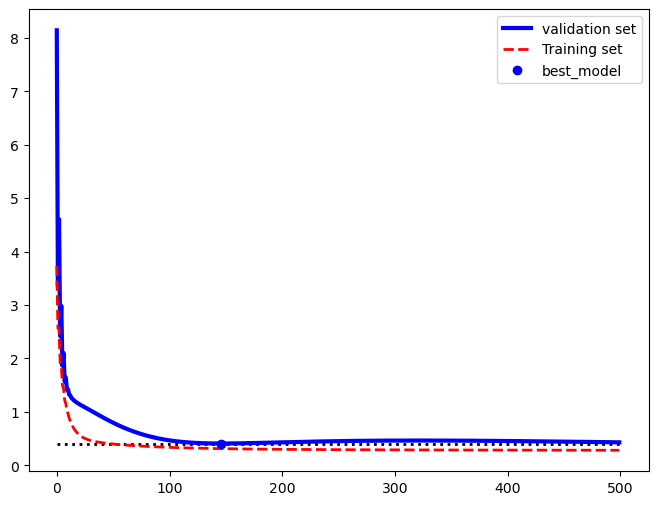

In [37]:
# 시각화
import matplotlib.pyplot as plt
best_epoch = np.argmin(val_erros)
fig, ax = plt.subplots(figsize=(8,6))
ax.plot([0, n_epochs], [best_valid_rmse, best_valid_rmse], 'k:', linewidth=2)
# erros로 덮어주기
ax.plot(val_erros, 'b-', linewidth=3, label='validation set')
ax.plot(train_erros, 'r--', linewidth=2, label='Training set')
# best_epoch 위치 표시
ax.plot(best_epoch, best_valid_rmse, 'bo', label='best_model')
# 라벨값을 범주로
plt.legend()


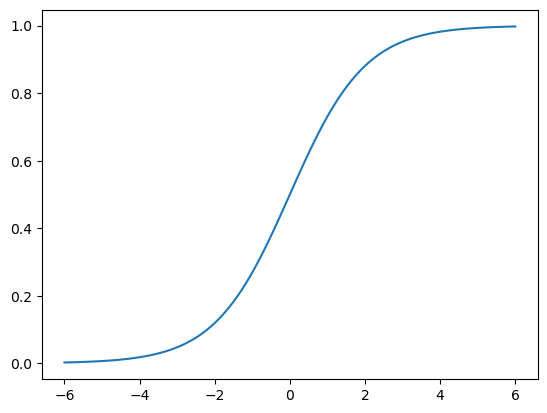

In [44]:
# 로지스틱 회귀 => 분류모델
import matplotlib.pylab as plt
lim = 6
t = np.linspace(-lim, lim, 100)
sig = 1 / (1+np.exp(-t))
# 계산된 값을 s자곡선으로 그려준다
plt.plot(t,sig)

In [49]:
# 분류 데이터 만들기
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
x, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,  # 실제로 중요한 feature
    n_redundant=0,  # informative 조합으로 만든 feature
    n_classes=2,
    random_state=42
)

In [ ]:
# 확률기반으로 변경하여 0과 1로 나타내어 알 수 있음
logistic = LogisticRegression()
logistic.fit(x,y)
y_pred = logistic.predict(x[:5])
print(y_pred)
y_pred_proba = logistic.predict_proba(x[:5])
print(y_pred_proba)

[0 1 1 1 1]
[[0.7118167  0.2881833 ]
 [0.08912468 0.91087532]
 [0.14452349 0.85547651]
 [0.00427267 0.99572733]
 [0.10396494 0.89603506]]


# [7교시]
- 선형으로 처리하기 힘든것들은 다항회귀로 처리한다

In [ ]:
# 데이터는 선택
# 전처리(결측치, 이상치, 표준화)
# 1.모델선택
# 2.모델학습
# 3.모델평가
# 1, 2, 3 반복하면서 모델 개선 혹은 모델 교체

In [1]:
# 시험환경 세팅 (코드 변경 X)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

def exam_data_load(df, target, id_name="", null_name=""):
    if id_name == "":
        df = df.reset_index().rename(columns={"index": "id"})
        id_name = 'id'
    else:
        id_name = id_name
    
    if null_name != "":
        df[df == null_name] = np.nan
    
    X_train, X_test = train_test_split(df, test_size=0.2, random_state=2021)
    
    y_train = X_train[[id_name, target]]
    X_train = X_train.drop(columns=[target])

    
    y_test = X_test[[id_name, target]]
    X_test = X_test.drop(columns=[target])
    return X_train, X_test, y_train, y_test 
    
df = pd.read_csv("C:\\python-src\\input\\pima-indians-diabetes-database\\diabetes.csv")
X_train, X_test, y_train, y_test = exam_data_load(df, target='Outcome')

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((614, 9), (154, 9), (614, 2), (154, 2))

In [ ]:
import pandas as pd
import sklearn
from sklearn.ensemble import RandomForestClassifier
X_train.drop('id',axis=1,inplace=True)
X_test.drop('id',axis=1,inplace=True)
model = RandomForestClassifier() 
model.fit(X_train, y_train['Outcome'])
predictions = model.predict(X_test)
round(model.score(X_train, y_train['Outcome']) * 100, 2)
output = pd.DataFrame({'idx': X_test.index, 'Outcome': predictions})
output.to_csv('1234567.csv', index=False)
round(model.score(X_test, y_test['Outcome']) * 100, 2) 

74.68

# [8교시]

- 강사님이 한것

In [ ]:
# 데이터는 선택
# 전처리(결측치, 이상치, 표준화)
# 1.모델선택
# 2.모델학습
# 3.모델평가
# 1, 2, 3 반복하면서 모델 개선 혹은 모델 교체

In [28]:
from glob import glob
import pandas as pd
df = pd.read_csv("diabetes.csv")
df['Outcome'].value_counts()
# 분류문제, 대표적인 불균형, classification_report ??

Outcome
0    500
1    268
Name: count, dtype: int64

<Axes: xlabel='Outcome', ylabel='count'>

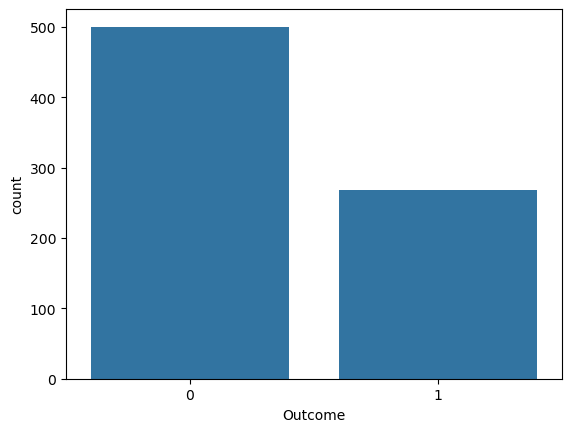

In [32]:
# 이상치
# x = df.
# y = 
# df['Pregnancies'].quantile(0.75)
# 시각화를통해 이상치 여부 확인
# 이상치있는 컬럼은 제거
# 모델 선택 sgd.. logisticrregression tree, randomforestregression...
# 평가

import seaborn as sns
sns.countplot(x='Outcome', data=df)

In [35]:
x = df.drop('Outcome',axis=1).to_numpy()
y = df['Outcome']
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report

pipeline = Pipeline([
    ('scale', StandardScaler()),
    ('rdf', RandomForestClassifier(random_state=42, n_estimators=500))
])
y_predict = cross_val_predict(pipeline, x, y, cv=5)
print(classification_report(y, y_predict))

              precision    recall  f1-score   support

           0       0.79      0.87      0.83       500
           1       0.70      0.58      0.64       268

    accuracy                           0.77       768
   macro avg       0.75      0.72      0.73       768
weighted avg       0.76      0.77      0.76       768

